In [1]:
# Customer Churn Prediction - IBM Telco Dataset
# Group Members: Daniel Eckman, Cole Compton, Melanie Vogt

# Goal:
# Build a model that predicts whether a customer will churn,
# then identify the features that contribute most to churn.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
# Load Data
df = pd.read_excel("Telco_customer_churn.xlsx")

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (7043, 33)
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Clean Data
# Drop columns that are IDs, too detailed, or leak churn information
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

df = df.drop(columns=drop_cols, errors="ignore")

# Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

# Use Churn Value as the target
# 1 = churned, 0 = stayed
df = df.rename(columns={"Churn Value": "Churn"})

print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

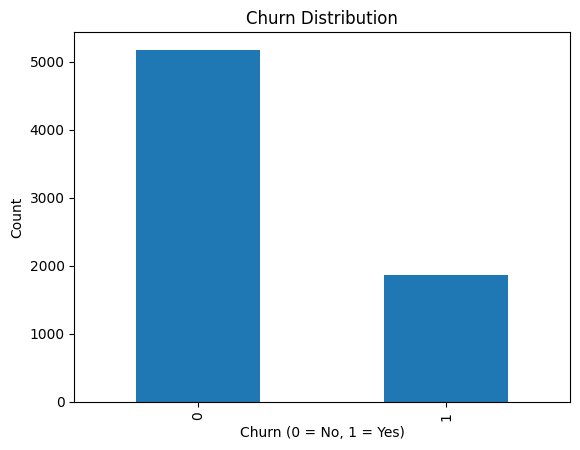

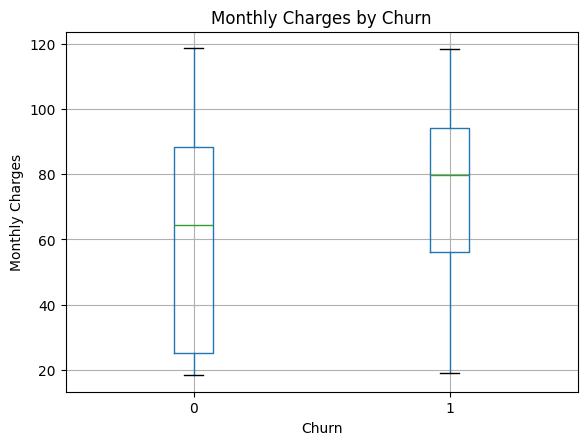

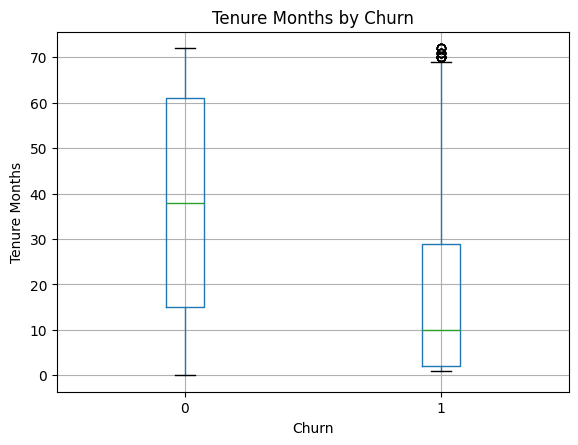

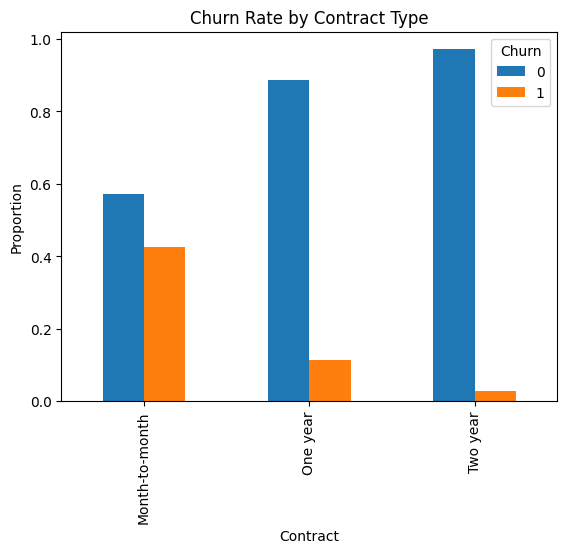

In [5]:
# Show data plots
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

df.boxplot(column="Monthly Charges", by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

df.boxplot(column="Tenure Months", by="Churn")
plt.title("Tenure Months by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.show()

pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Proportion")
plt.show()

In [6]:
# Encode variables
df_encoded = pd.get_dummies(df, drop_first=True)

print("New shape:", df_encoded.shape)
df_encoded.head()

# Split data
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

New shape: (7043, 31)
Training set: (5634, 30)
Test set: (1409, 30)


Logistic Regression Results
Accuracy: 0.7430801987224982
Precision: 0.5104895104895105
Recall: 0.7807486631016043
F1 Score: 0.6173361522198731

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



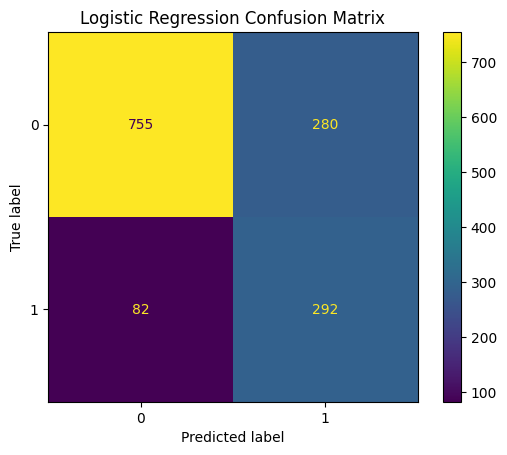

,Feature,Coefficient,Abs
0,Tenure Months,-1.193788,1.193788
1,Monthly Charges,-0.847195,0.847195
10,Internet Service_Fiber optic,0.691924,0.691924
6,Dependents_Yes,-0.691219,0.691219
25,Contract_Two year,-0.609402,0.609402
2,Total Charges,0.496175,0.496175
24,Contract_One year,-0.322299,0.322299
23,Streaming Movies_Yes,0.249412,0.249412
21,Streaming TV_Yes,0.238110,0.238110
9,Multiple Lines_Yes,0.194495,0.194495


In [7]:
# Model 1: Logistic Regression
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

log_model.fit(X_train_scaled, y_train)

# Evaluate model
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Feature Importance
log_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance["Abs"] = log_importance["Coefficient"].abs()
log_importance = log_importance.sort_values(by="Abs", ascending=False)

log_importance.head(15)

Random Forest Results
Accuracy: 0.7892122072391767
Precision: 0.6245954692556634
Recall: 0.516042780748663
F1 Score: 0.5651537335285505

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



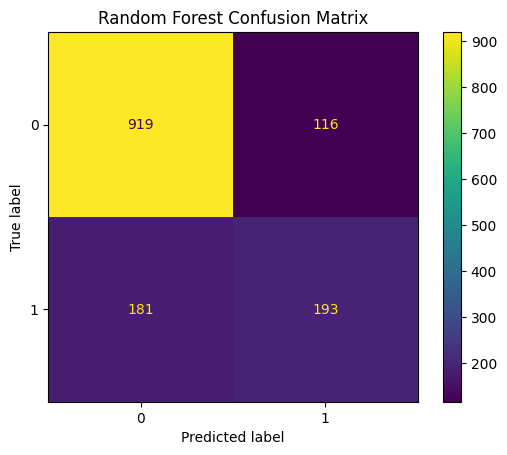

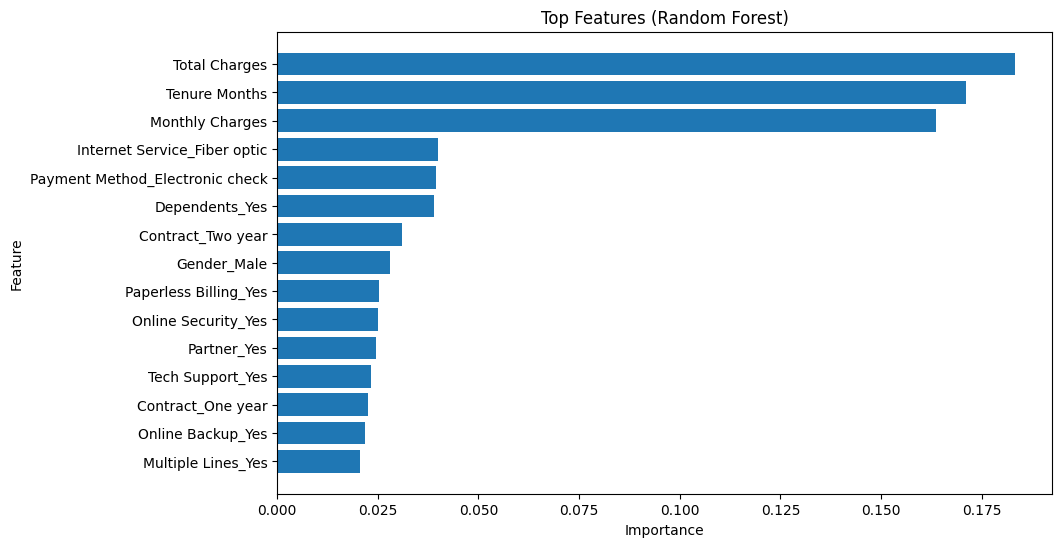

In [8]:
# Model 2: Random Forest
# Train Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Evaluate Model
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
rf_importance = rf_importance.sort_values(by="Importance", ascending=False)
rf_importance.head(15)

top_rf = rf_importance.head(15).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.title("Top Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [9]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.743080,0.510490,0.780749,0.617336
1,Random Forest,0.789212,0.624595,0.516043,0.565154


In [10]:
# Interpretation:
# Logistic Regression:
# Positive coefficients increase likelihood of churn.
# Negative coefficients decrease likelihood of churn.
#
# Random Forest:
# Higher importance means the feature had more influence on predictions.